# Baseline CNN Skin Lesion Classifier — HAM10000

**Dataset:** HAM10000 · 7 classes: MEL, NV, BCC, AKIEC, BKL, DF, VASC  
**Augmentation:** Real images + GAN-generated / Reinhard-normalised images  
**Architecture:** Custom CNN built from scratch — no pretrained weights  
**Training:** Full training from random initialization, AdamW + CosineAnnealingLR, AMP mixed precision  
**Purpose:** Non-transfer-learning baseline against EfficientNet-B3, DenseNet-121, and ResNet-50

---
## 1 · Imports & Config

In [1]:
# ── Standard library ───────────────────────────────────────────────────────
import random
import time
import logging
from pathlib import Path

# ── Numerical / ML ──────────────────────────────────────────────────────────
import numpy as np
import torch
import torch.nn as nn
from torch.amp import GradScaler
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T

# ── Data helpers ────────────────────────────────────────────────────────────
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    roc_curve,
    auc as sklearn_auc,
    confusion_matrix,
    f1_score,
)
from sklearn.preprocessing import label_binarize

# ── Progress / Plotting ─────────────────────────────────────────────────────
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# ═══════════════════════════════════════════════════════════════════════════════
#  HYPER-PARAMETERS  (edit here only)
# ═══════════════════════════════════════════════════════════════════════════════
IMG_SIZE   = 224
BATCH_SIZE = 8
EPOCHS     = 30
LR         = 1e-3        # Higher LR — no pretrained backbone to preserve
SEED       = 42

device   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_CUDA = device.type == 'cuda'

CLASS_NAMES = ['MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']
NUM_CLASSES  = len(CLASS_NAMES)

# ── Paths ───────────────────────────────────────────────────────────────────
ROOT      = Path().cwd()                             # notebook lives in skin cancer/
DATA_ROOT = ROOT / 'dataset' / 'processed_images'
CKPT_DIR  = ROOT / 'checkpoints'
CKPT_PATH = CKPT_DIR / 'baseline_cnn_best.pt'
LOG_PATH  = ROOT.parent / 'results' / 'logs' / 'training.log'

CKPT_DIR.mkdir(parents=True, exist_ok=True)
LOG_PATH.parent.mkdir(parents=True, exist_ok=True)

print(f'Device    : {device}')
print(f'Data root : {DATA_ROOT.resolve()}')
print(f'Checkpoint: {CKPT_PATH.resolve()}')
print(f'Log file  : {LOG_PATH.resolve()}')

Device    : cuda
Data root : C:\Users\shara\Desktop\paper_learning\skin cancer\dataset\processed_images
Checkpoint: C:\Users\shara\Desktop\paper_learning\skin cancer\checkpoints\baseline_cnn_best.pt
Log file  : C:\Users\shara\Desktop\paper_learning\results\logs\training.log


In [2]:
# ── Reproducibility ─────────────────────────────────────────────────────────
def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if USE_CUDA:
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark     = False

seed_everything(SEED)
print('Seeds fixed \u2713')

Seeds fixed ✓


In [3]:
# ── Logger setup ────────────────────────────────────────────────────────────
def get_logger(log_path: Path) -> logging.Logger:
    logger = logging.getLogger('BaselineCNN')
    logger.setLevel(logging.INFO)
    logger.handlers.clear()  # avoid duplicate handlers on re-run

    fmt = logging.Formatter(
        '%(asctime)s | %(levelname)-8s | %(message)s',
        datefmt='%Y-%m-%d %H:%M:%S',
    )

    fh = logging.FileHandler(str(log_path), mode='a', encoding='utf-8')
    fh.setFormatter(fmt)
    logger.addHandler(fh)

    ch = logging.StreamHandler()
    ch.setFormatter(fmt)
    logger.addHandler(ch)

    return logger


logger = get_logger(LOG_PATH)
logger.info('=' * 70)
logger.info('Baseline CNN HAM10000 Training Run')
logger.info(
    f'Device={device} | IMG_SIZE={IMG_SIZE} | BATCH_SIZE={BATCH_SIZE}'
    f' | EPOCHS={EPOCHS} | LR={LR} | SEED={SEED}'
)
logger.info('=' * 70)

2026-07-29 00:20:38 | INFO     | ======================================================================
2026-07-29 00:20:38 | INFO     | Baseline CNN HAM10000 Training Run
2026-07-29 00:20:38 | INFO     | Device=cuda | IMG_SIZE=224 | BATCH_SIZE=8 | EPOCHS=30 | LR=0.001 | SEED=42
2026-07-29 00:20:38 | INFO     | ======================================================================


---
## 2 · Dataset

In [4]:
# ── Transforms ──────────────────────────────────────────────────────────────
# Using ImageNet normalization for consistency with transfer-learning runs
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

In [5]:
# ── Dataset class ────────────────────────────────────────────────────────────
class SkinLesionDataset(Dataset):
    """Flat (filepath, label) dataset built from real/ and normalized/ sub-dirs."""

    def __init__(self, samples, transform=None):
        self.samples   = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label


def build_sample_list(data_root: Path, class_names: list) -> list:
    """
    Scan processed_images/{cls}/real/ and normalized/ for every class.
    normalized/ is silently skipped if it does not exist (e.g. NV).
    Uses Path.glob (not glob.glob) as required.
    """
    all_samples = []
    for cls_idx, cls_name in enumerate(class_names):
        cls_dir  = data_root / cls_name
        sub_dirs = [cls_dir / 'real']
        norm_dir = cls_dir / 'normalized'
        if norm_dir.exists():
            sub_dirs.append(norm_dir)
        else:
            print(f'  [INFO] {cls_name}/normalized/ not found - skipped (expected for NV)')

        for sub_dir in sub_dirs:
            if not sub_dir.exists():
                print(f'  [WARN] {sub_dir} does not exist - skipped')
                continue
            imgs = (
                list(sub_dir.glob('*.jpg'))
                + list(sub_dir.glob('*.jpeg'))
                + list(sub_dir.glob('*.png'))
            )
            all_samples.extend([(p, cls_idx) for p in imgs])

    return all_samples


# Build master list
all_samples = build_sample_list(DATA_ROOT, CLASS_NAMES)
all_labels  = [s[1] for s in all_samples]

print(f'\nTotal images found: {len(all_samples)}')
for i, cls in enumerate(CLASS_NAMES):
    cnt = sum(1 for lbl in all_labels if lbl == i)
    print(f'  {cls:>6}: {cnt}')

  [INFO] NV/normalized/ not found - skipped (expected for NV)

Total images found: 46935
     MEL: 6705
      NV: 6705
     BCC: 6705
   AKIEC: 6705
     BKL: 6705
      DF: 6705
    VASC: 6705


In [6]:
# ── Stratified 80 / 10 / 10 split ───────────────────────────────────────────
train_val_samples, test_samples, train_val_labels, test_labels = train_test_split(
    all_samples, all_labels,
    test_size=0.10, random_state=SEED, stratify=all_labels,
)

train_samples, val_samples, train_labels, val_labels = train_test_split(
    train_val_samples, train_val_labels,
    test_size=0.111,   # 0.111 × 0.90 ≈ 0.10 of total
    random_state=SEED, stratify=train_val_labels,
)


def print_split_counts(split_name, labels):
    print(f'\n{split_name} split ({len(labels)} total):')
    for i, cls in enumerate(CLASS_NAMES):
        cnt = labels.count(i)
        print(f'  {cls:>6}: {cnt}')


print_split_counts('Train', train_labels)
print_split_counts('Val',   val_labels)
print_split_counts('Test',  test_labels)

logger.info(
    f'Split sizes -> Train: {len(train_samples)}'
    f' | Val: {len(val_samples)} | Test: {len(test_samples)}'
)

# Log per-class counts for each split
for split_name, labels in [('Train', train_labels), ('Val', val_labels), ('Test', test_labels)]:
    for i, cls in enumerate(CLASS_NAMES):
        cnt = labels.count(i)
        logger.info(f'  [{split_name}] {cls}: {cnt}')

2026-07-29 00:20:53 | INFO     | Split sizes -> Train: 37552 | Val: 4689 | Test: 4694
2026-07-29 00:20:53 | INFO     |   [Train] MEL: 5365
2026-07-29 00:20:53 | INFO     |   [Train] NV: 5365
2026-07-29 00:20:53 | INFO     |   [Train] BCC: 5364
2026-07-29 00:20:53 | INFO     |   [Train] AKIEC: 5365
2026-07-29 00:20:53 | INFO     |   [Train] BKL: 5364
2026-07-29 00:20:53 | INFO     |   [Train] DF: 5365
2026-07-29 00:20:53 | INFO     |   [Train] VASC: 5364
2026-07-29 00:20:53 | INFO     |   [Val] MEL: 670
2026-07-29 00:20:53 | INFO     |   [Val] NV: 670
2026-07-29 00:20:53 | INFO     |   [Val] BCC: 670
2026-07-29 00:20:53 | INFO     |   [Val] AKIEC: 669
2026-07-29 00:20:53 | INFO     |   [Val] BKL: 670
2026-07-29 00:20:53 | INFO     |   [Val] DF: 670
2026-07-29 00:20:53 | INFO     |   [Val] VASC: 670
2026-07-29 00:20:53 | INFO     |   [Test] MEL: 670
2026-07-29 00:20:53 | INFO     |   [Test] NV: 670
2026-07-29 00:20:53 | INFO     |   [Test] BCC: 671
2026-07-29 00:20:53 | INFO     |   [Tes


Train split (37552 total):
     MEL: 5365
      NV: 5365
     BCC: 5364
   AKIEC: 5365
     BKL: 5364
      DF: 5365
    VASC: 5364

Val split (4689 total):
     MEL: 670
      NV: 670
     BCC: 670
   AKIEC: 669
     BKL: 670
      DF: 670
    VASC: 670

Test split (4694 total):
     MEL: 670
      NV: 670
     BCC: 671
   AKIEC: 671
     BKL: 671
      DF: 670
    VASC: 671


In [7]:
# ── WeightedRandomSampler ────────────────────────────────────────────────────
class_counts   = np.bincount(train_labels, minlength=NUM_CLASSES).astype(float)
class_weights  = 1.0 / np.where(class_counts == 0, 1.0, class_counts)
sample_weights = np.array([class_weights[lbl] for lbl in train_labels])

sampler = WeightedRandomSampler(
    weights     = torch.DoubleTensor(sample_weights),
    num_samples = len(train_samples),
    replacement = True,
)

# ── Datasets ────────────────────────────────────────────────────────────────
train_ds = SkinLesionDataset(train_samples, transform=train_transform)
val_ds   = SkinLesionDataset(val_samples,   transform=eval_transform)
test_ds  = SkinLesionDataset(test_samples,  transform=eval_transform)

# ── DataLoaders ─────────────────────────────────────────────────────────────
loader_kwargs = dict(pin_memory=True, num_workers=0) if USE_CUDA else {}

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          sampler=sampler, **loader_kwargs)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                          shuffle=False, **loader_kwargs)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE,
                          shuffle=False, **loader_kwargs)

print(f'Train batches: {len(train_loader)} | '
      f'Val batches: {len(val_loader)} | '
      f'Test batches: {len(test_loader)}')

Train batches: 4694 | Val batches: 587 | Test batches: 587


---
## 3 · Model

In [8]:
# ── Baseline CNN (built from scratch — NO pretrained weights) ────────────────
class BaselineCNN(nn.Module):
    """
    Custom CNN built entirely from scratch with random initialization.
    Architecture:
      - 4 conv blocks: Conv2d -> BatchNorm2d -> ReLU -> MaxPool2d(2)
        channel progression: 3 -> 32 -> 64 -> 128 -> 256
      - AdaptiveAvgPool2d(1) to handle any spatial size
      - Classifier: Flatten -> Linear(256,128) -> ReLU -> Dropout(0.4) -> Linear(128,7)
    Weights initialised with Kaiming Normal (He init).
    """

    def __init__(self, num_classes: int = 7):
        super().__init__()

        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )

        self.features = nn.Sequential(
            conv_block(3,   32),   # 224 -> 112
            conv_block(32,  64),   # 112 -> 56
            conv_block(64,  128),  # 56  -> 28
            conv_block(128, 256),  # 28  -> 14
        )

        self.pool = nn.AdaptiveAvgPool2d(1)  # 14 -> 1 (works for any spatial dim)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes),
        )

        self._init_weights()

    def _init_weights(self):
        """Kaiming Normal init for all Conv2d layers."""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x


# ── Build model ───────────────────────────────────────────────────────────────
model = BaselineCNN(num_classes=NUM_CLASSES).to(device)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
logger.info(f'Model: BaselineCNN | trainable params: {trainable_params:,}')
print(f'  Trainable params: {trainable_params:,}')

# ── Loss / Optimizer / Scheduler ────────────────────────────────────────────
# No freeze/unfreeze — train everything from epoch 1
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR, weight_decay=1e-4,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler    = GradScaler('cuda', enabled=USE_CUDA)

print('\nModel built and ready \u2713')

2026-07-29 00:21:03 | INFO     | Model: BaselineCNN | trainable params: 422,695


  Trainable params: 422,695

Model built and ready ✓


---
## 4 · Training Loop

In [9]:
def run_epoch(loader, model, criterion, optimizer=None, scaler=None,
              phase='train', epoch=1, n_epochs=1):
    is_train = (phase == 'train')
    model.train() if is_train else model.eval()

    total_loss, correct, total = 0.0, 0, 0
    running_loss = 0.0

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        pbar = tqdm(
            loader,
            desc=f"[BaselineCNN] Epoch {epoch}/{n_epochs} | {phase}",
            leave=True
        )
        for imgs, labels in pbar:
            imgs, labels = imgs.to(device), labels.to(device)
            amp_enabled = USE_CUDA and is_train
            with torch.amp.autocast(device_type=device.type, enabled=amp_enabled):
                logits = model(imgs)
            loss = criterion(logits.float(), labels)

            if is_train:
                optimizer.zero_grad()
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

            running_loss += loss.item()
            total_loss   += loss.item() * imgs.size(0)
            preds         = logits.argmax(dim=1)
            correct      += (preds == labels).sum().item()
            total        += imgs.size(0)

            pbar.set_postfix(
                Loss=f"{running_loss / (pbar.n + 1):.4f}",
                Acc =f"{correct / total * 100:.2f}%"
            )

    return total_loss / total, correct / total



# ── Training loop ────────────────────────────────────────────────────────────
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()

    # No freeze/unfreeze phase — train all parameters from epoch 1
    train_loss, train_acc = run_epoch(
        train_loader, model, criterion,
        optimizer=optimizer, scaler=scaler, phase='train',
        epoch=epoch, n_epochs=EPOCHS,
    )
    val_loss, val_acc = run_epoch(
        val_loader, model, criterion, phase='val',
        epoch=epoch, n_epochs=EPOCHS,
    )
    scheduler.step()

    epoch_time = time.time() - epoch_start

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    log_msg = (
        f'Epoch [{epoch:02d}/{EPOCHS}]'
        f' | Time: {epoch_time:.1f}s'
        f' | Train Loss: {train_loss:.4f}  Train Acc: {train_acc*100:.2f}%'
        f' | Val Loss: {val_loss:.4f}  Val Acc: {val_acc*100:.2f}%'
    )
    logger.info(log_msg)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch':             epoch,
            'model_state_dict':  model.state_dict(),
            'optimizer_state':   optimizer.state_dict(),
            'val_acc':           val_acc,
            'val_loss':          val_loss,
        }, CKPT_PATH)
        logger.info(f'  \u2713 Checkpoint saved (val_acc={val_acc*100:.2f}%)')

logger.info('Training complete.')

[BaselineCNN] Epoch 1/30 | train: 100%|██████████| 4694/4694 [04:10<00:00, 18.72it/s, Acc=40.91%, Loss=1.5139]
[BaselineCNN] Epoch 1/30 | val: 100%|██████████| 587/587 [00:11<00:00, 49.03it/s, Acc=61.91%, Loss=1.0500]
2026-07-29 00:25:30 | INFO     | Epoch [01/30] | Time: 262.7s | Train Loss: 1.5135  Train Acc: 40.91% | Val Loss: 1.0448  Val Acc: 61.91%
2026-07-29 00:25:30 | INFO     |   ✓ Checkpoint saved (val_acc=61.91%)
[BaselineCNN] Epoch 2/30 | train: 100%|██████████| 4694/4694 [04:13<00:00, 18.54it/s, Acc=52.97%, Loss=1.2407]
[BaselineCNN] Epoch 2/30 | val: 100%|██████████| 587/587 [00:11<00:00, 49.57it/s, Acc=69.48%, Loss=0.8790]
2026-07-29 00:29:55 | INFO     | Epoch [02/30] | Time: 265.1s | Train Loss: 1.2405  Train Acc: 52.97% | Val Loss: 0.8745  Val Acc: 69.48%
2026-07-29 00:29:55 | INFO     |   ✓ Checkpoint saved (val_acc=69.48%)
[BaselineCNN] Epoch 3/30 | train: 100%|██████████| 4694/4694 [04:23<00:00, 17.82it/s, Acc=62.48%, Loss=1.0276]
[BaselineCNN] Epoch 3/30 | val: 100

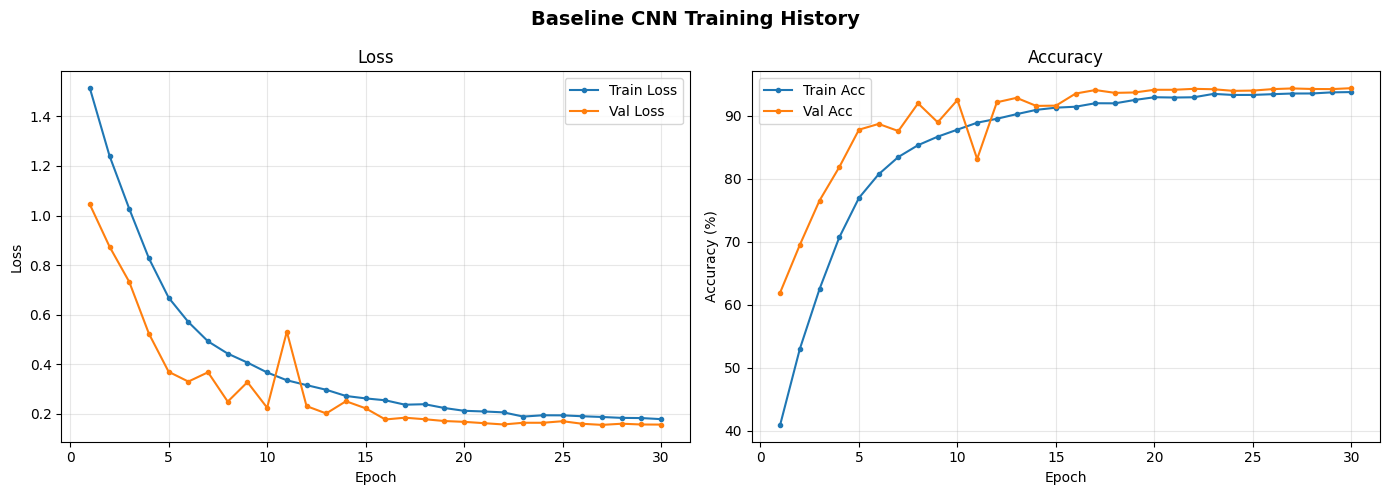

Saved -> baseline_cnn_training_curves.png


In [10]:
# ── Training history plot ─────────────────────────────────────────────────────
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Baseline CNN Training History', fontsize=14, fontweight='bold')

# Loss subplot
axes[0].plot(epochs_range, history['train_loss'], label='Train Loss', marker='o', markersize=3)
axes[0].plot(epochs_range, history['val_loss'],   label='Val Loss',   marker='o', markersize=3)
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy subplot
axes[1].plot(epochs_range, [a * 100 for a in history['train_acc']], label='Train Acc', marker='o', markersize=3)
axes[1].plot(epochs_range, [a * 100 for a in history['val_acc']],   label='Val Acc',   marker='o', markersize=3)
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('baseline_cnn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> baseline_cnn_training_curves.png')

---
## 5 · Evaluation on Test Set

In [11]:
# ── Load best checkpoint ─────────────────────────────────────────────────────
ckpt = torch.load(CKPT_PATH, map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
logger.info(
    f'Loaded checkpoint from epoch {ckpt["epoch"]} '
    f'(val_acc={ckpt["val_acc"]*100:.2f}%)'
)
print(f'Checkpoint loaded: epoch {ckpt["epoch"]}, val_acc={ckpt["val_acc"]*100:.2f}%')

2026-07-29 02:38:00 | INFO     | Loaded checkpoint from epoch 30 (val_acc=94.35%)


Checkpoint loaded: epoch 30, val_acc=94.35%


In [12]:
# ── Run inference on test set ────────────────────────────────────────────────
model.eval()
all_preds       = []
all_labels_test = []
all_probs       = []

with torch.no_grad():
    pbar = tqdm(test_loader, desc='[BaselineCNN] Evaluating test set', leave=True)
    for imgs, labels in pbar:
        imgs   = imgs.to(device)
        logits = model(imgs)
        probs  = torch.softmax(logits.float(), dim=1)
        preds  = logits.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels_test.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds       = np.array(all_preds)
all_labels_test = np.array(all_labels_test)
all_probs       = np.array(all_probs)

# ── Overall accuracy ─────────────────────────────────────────────────────────
test_acc = (all_preds == all_labels_test).mean()
logger.info(f'Test Accuracy: {test_acc*100:.2f}%')
print(f'\nTest Accuracy: {test_acc*100:.2f}%')

[BaselineCNN] Evaluating test set: 100%|██████████| 587/587 [00:11<00:00, 51.96it/s]
2026-07-29 02:38:11 | INFO     | Test Accuracy: 94.16%



Test Accuracy: 94.16%


In [13]:
# ── Classification report ────────────────────────────────────────────────────
report = classification_report(
    all_labels_test, all_preds,
    target_names=CLASS_NAMES,
    digits=4
)
print('\nClassification Report:')
print(report)
logger.info('\n' + report)

# ── Macro / Weighted F1 ──────────────────────────────────────────────────────
macro_f1    = f1_score(all_labels_test, all_preds, average='macro')
weighted_f1 = f1_score(all_labels_test, all_preds, average='weighted')
logger.info(f'Macro F1: {macro_f1:.4f} | Weighted F1: {weighted_f1:.4f}')
print(f'Macro F1   : {macro_f1:.4f}')
print(f'Weighted F1: {weighted_f1:.4f}')

2026-07-29 02:38:11 | INFO     | 
              precision    recall  f1-score   support

         MEL     0.9617    0.8627    0.9095       670
          NV     0.7764    0.9642    0.8602       670
         BCC     0.9627    0.9613    0.9620       671
       AKIEC     0.9923    0.9598    0.9758       671
         BKL     0.9511    0.8703    0.9089       671
          DF     1.0000    0.9866    0.9932       670
        VASC     0.9925    0.9866    0.9895       671

    accuracy                         0.9416      4694
   macro avg     0.9481    0.9416    0.9427      4694
weighted avg     0.9481    0.9416    0.9428      4694

2026-07-29 02:38:11 | INFO     | Macro F1: 0.9427 | Weighted F1: 0.9428



Classification Report:
              precision    recall  f1-score   support

         MEL     0.9617    0.8627    0.9095       670
          NV     0.7764    0.9642    0.8602       670
         BCC     0.9627    0.9613    0.9620       671
       AKIEC     0.9923    0.9598    0.9758       671
         BKL     0.9511    0.8703    0.9089       671
          DF     1.0000    0.9866    0.9932       670
        VASC     0.9925    0.9866    0.9895       671

    accuracy                         0.9416      4694
   macro avg     0.9481    0.9416    0.9427      4694
weighted avg     0.9481    0.9416    0.9428      4694

Macro F1   : 0.9427
Weighted F1: 0.9428


2026-07-29 02:38:11 | INFO     |   AUC [MEL]: 0.9917
2026-07-29 02:38:11 | INFO     |   AUC [NV]: 0.9923
2026-07-29 02:38:11 | INFO     |   AUC [BCC]: 0.9990
2026-07-29 02:38:11 | INFO     |   AUC [AKIEC]: 0.9992
2026-07-29 02:38:11 | INFO     |   AUC [BKL]: 0.9938
2026-07-29 02:38:11 | INFO     |   AUC [DF]: 0.9997
2026-07-29 02:38:11 | INFO     |   AUC [VASC]: 0.9993
2026-07-29 02:38:11 | INFO     | Macro AUC: 0.9964



Per-class AUC-ROC:
     MEL: 0.9917
      NV: 0.9923
     BCC: 0.9990
   AKIEC: 0.9992
     BKL: 0.9938
      DF: 0.9997
    VASC: 0.9993
  Macro AUC: 0.9964


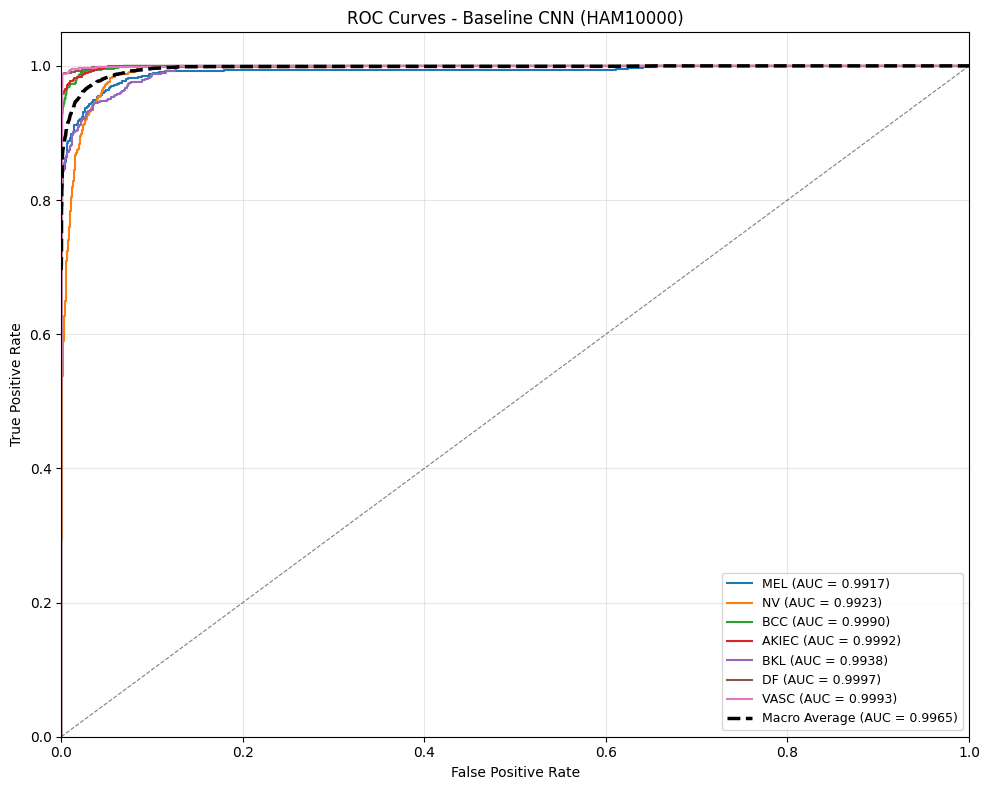

Saved -> baseline_cnn_roc_curves.png


In [14]:
# ── Per-class AUC-ROC ────────────────────────────────────────────────────────
labels_bin = label_binarize(all_labels_test, classes=list(range(NUM_CLASSES)))

# Per-class AUC
per_class_auc = roc_auc_score(
    labels_bin, all_probs,
    multi_class='ovr', average=None
)
macro_auc = roc_auc_score(
    labels_bin, all_probs,
    multi_class='ovr', average='macro'
)

print('\nPer-class AUC-ROC:')
for cls, auc_val in zip(CLASS_NAMES, per_class_auc):
    logger.info(f'  AUC [{cls}]: {auc_val:.4f}')
    print(f'  {cls:>6}: {auc_val:.4f}')
logger.info(f'Macro AUC: {macro_auc:.4f}')
print(f'  Macro AUC: {macro_auc:.4f}')


# ── ROC curves — all 7 classes + macro average on one figure ─────────────────
fig, ax = plt.subplots(figsize=(10, 8))

colors = plt.cm.tab10.colors  # 10-color cycle
for i, cls in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(labels_bin[:, i], all_probs[:, i])
    roc_auc_val = sklearn_auc(fpr, tpr)
    ax.plot(fpr, tpr, color=colors[i], lw=1.5,
            label=f'{cls} (AUC = {roc_auc_val:.4f})')

# Macro average ROC
all_fpr = np.unique(np.concatenate([roc_curve(labels_bin[:, i], all_probs[:, i])[0]
                                    for i in range(NUM_CLASSES)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(labels_bin[:, i], all_probs[:, i])
    mean_tpr += np.interp(all_fpr, fpr, tpr)
mean_tpr /= NUM_CLASSES
macro_roc_auc = sklearn_auc(all_fpr, mean_tpr)
ax.plot(all_fpr, mean_tpr, color='black', lw=2.5, linestyle='--',
        label=f'Macro Average (AUC = {macro_roc_auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=0.8, alpha=0.5)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves - Baseline CNN (HAM10000)')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('baseline_cnn_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> baseline_cnn_roc_curves.png')

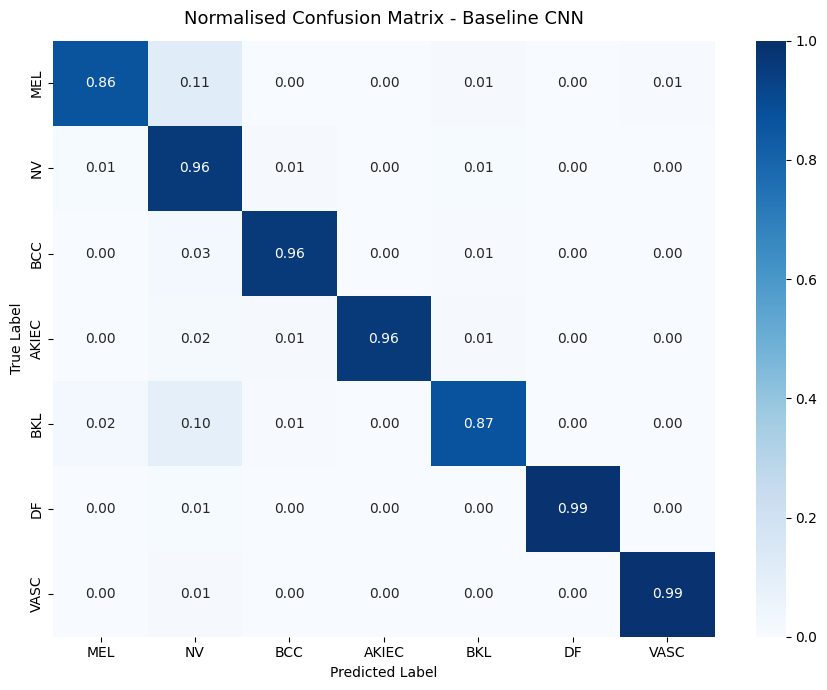

Saved -> baseline_cnn_confusion_matrix.png


In [15]:
# ── Normalised Confusion Matrix ───────────────────────────────────────────────
cm = confusion_matrix(all_labels_test, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # normalize by true label

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=ax,
    vmin=0.0,
    vmax=1.0,
)
ax.set_title('Normalised Confusion Matrix - Baseline CNN', fontsize=13, pad=12)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')

plt.tight_layout()
plt.savefig('baseline_cnn_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> baseline_cnn_confusion_matrix.png')